# Hyperparameter Sweep Analysis

Systematic sweep of key hyperparameters (learning rate, hidden channels, num layers, dropout) for all models (GCN, GraphSAGE, GIN, DGI) across all four datasets.

**Datasets:** Cora (node), Karate (node), Enzymes (graph), Proteins (graph)  
**Models:** GCN, GraphSAGE, GIN (supervised) + DGI (unsupervised, separate section)  
**Note:** Each run uses `epochs=150` for reliable convergence. Results show relative trends, not peak accuracy.

>

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from torch_geometric.loader import DataLoader

from main import load_dataset, build_model, set_seed
from train import train_one_epoch, train_dgi_pretrain, train_dgi_pretrain_graph
from test import evaluate
from parameters import ModelParams, TrainParams, DataParams

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SUPERVISED_MODELS = ['gcn', 'graphsage', 'gin']
ALL_DATASETS = ['cora', 'karate', 'enzymes', 'proteins']
MODEL_COLORS = {'gcn': '#2196F3', 'graphsage': '#4CAF50', 'gin': '#FF9800', 'dgi': '#9C27B0'}

print('Setup complete. Device:', DEVICE)

Setup complete. Device: cuda


In [2]:
def run_experiment(
    model_name, dataset_name,
    lr=0.01, hidden_channels=64, num_layers=2, dropout=0.5,
    epochs=150, patience=0, pretrain_epochs=150, seed=42
):
    """Run one training experiment and return val/test accuracy."""
    set_seed(seed)

    data_params = DataParams(dataset_name=dataset_name, seed=seed)
    model_params = ModelParams(
        model_name=model_name,
        hidden_channels=hidden_channels,
        num_layers=num_layers,
        dropout=dropout,
    )
    train_params = TrainParams(
        lr=lr, epochs=epochs, patience=patience,
        pretrain_epochs=pretrain_epochs,
    )

    ds_info = load_dataset(data_params)
    task = ds_info['task']

    data = train_mask = val_mask = test_mask = None
    train_loader = val_loader = test_loader = None

    if task == 'node':
        data = ds_info['data'].to(DEVICE)
        train_mask = ds_info['train_mask'].to(DEVICE)
        val_mask   = ds_info['val_mask'].to(DEVICE)
        test_mask  = ds_info['test_mask'].to(DEVICE)
    else:
        bs = train_params.batch_size
        train_loader = DataLoader(ds_info['train_dataset'], batch_size=bs, shuffle=True)
        val_loader   = DataLoader(ds_info['val_dataset'],   batch_size=bs, shuffle=False)
        test_loader  = DataLoader(ds_info['test_dataset'],  batch_size=bs, shuffle=False)

    model = build_model(model_params, ds_info['num_features'], ds_info['num_classes'], task).to(DEVICE)

    # DGI Phase 1: unsupervised pre-training
    if model_name == 'dgi':
        pre_opt = torch.optim.Adam(model.parameters(), lr=lr)
        for _ in range(pretrain_epochs):
            if task == 'node':
                train_dgi_pretrain(model, data, pre_opt)
            else:
                train_dgi_pretrain_graph(model, train_loader, pre_opt, DEVICE)
        for param in model.dgi.encoder.parameters():
            param.requires_grad = False
        model.dgi.weight.requires_grad = False
        optimizer = torch.optim.Adam(model.classifier.parameters(), lr=lr)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_acc = 0.0
    best_state = model.state_dict()

    for _ in range(epochs):
        train_one_epoch(model, task, optimizer, DEVICE,
                        data=data, train_mask=train_mask, train_loader=train_loader)
        val_metrics = evaluate(model, task, DEVICE, data=data, mask=val_mask, loader=val_loader)
        if val_metrics['accuracy'] > best_val_acc:
            best_val_acc = val_metrics['accuracy']
            best_state = model.state_dict()

    model.load_state_dict(best_state)
    test_metrics = evaluate(model, task, DEVICE, data=data, mask=test_mask, loader=test_loader)
    return {'val_acc': best_val_acc, 'test_acc': test_metrics['accuracy']}


def sweep_param(param_name, values, models, datasets, fixed_kwargs=None):
    """Sweep one parameter across models and datasets. Returns a DataFrame."""
    fixed = fixed_kwargs or {}
    rows = []
    total = len(values) * len(models) * len(datasets)
    done = 0
    for model_name in models:
        for dataset_name in datasets:
            for val in values:
                kwargs = {param_name: val, **fixed}
                result = run_experiment(model_name, dataset_name, **kwargs)
                rows.append({
                    param_name: val,
                    'model': model_name,
                    'dataset': dataset_name,
                    'val_acc': result['val_acc'],
                    'test_acc': result['test_acc'],
                })
                done += 1
                print(f'  [{done}/{total}] {model_name} | {dataset_name} | {param_name}={val:.4g} '
                      f'→ val={result["val_acc"]:.3f}')
    return pd.DataFrame(rows)


def plot_sweep(df, param_name, title, axs):
    """2×2 grid: one subplot per dataset, lines per model."""
    datasets = ['cora', 'karate', 'enzymes', 'proteins']
    for ax, dataset in zip(axs.flat, datasets):
        sub = df[df['dataset'] == dataset]
        for model_name in sub['model'].unique():
            m = sub[sub['model'] == model_name]
            ax.plot(m[param_name], m['val_acc'],
                    marker='o', label=model_name.upper(),
                    color=MODEL_COLORS.get(model_name))
        ax.set_title(dataset.capitalize())
        ax.set_xlabel(param_name)
        ax.set_ylabel('Val Accuracy')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        if param_name == 'lr':
            ax.set_xscale('log')
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

print('Helper functions defined.')

Helper functions defined.


## 1. Learning Rate Sweep
How does the learning rate affect convergence for each model and dataset?

In [3]:
LR_VALUES = [0.0001, 0.001, 0.01, 0.1]
print('Running learning rate sweep...')
df_lr = sweep_param('lr', LR_VALUES, SUPERVISED_MODELS, ALL_DATASETS)
print('Done.')
df_lr

Running learning rate sweep...


  [1/48] gcn | cora | lr=0.0001 → val=0.474


  [2/48] gcn | cora | lr=0.001 → val=0.784


  [3/48] gcn | cora | lr=0.01 → val=0.784


  [4/48] gcn | cora | lr=0.1 → val=0.774


...

  [45/48] gin | proteins | lr=0.0001 → val=0.703


  [46/48] gin | proteins | lr=0.001 → val=0.730


  [47/48] gin | proteins | lr=0.01 → val=0.748


  [48/48] gin | proteins | lr=0.1 → val=0.577
Done.


,lr,model,dataset,val_acc,test_acc
0,0.0001,gcn,cora,0.474000,0.489000
1,0.0010,gcn,cora,0.784000,0.788000
2,0.0100,gcn,cora,0.784000,0.784000
3,0.1000,gcn,cora,0.774000,0.713000
4,0.0001,gcn,karate,0.000000,0.250000
5,0.0010,gcn,karate,0.666667,1.000000
6,0.0100,gcn,karate,1.000000,1.000000
7,0.1000,gcn,karate,1.000000,1.000000
8,0.0001,gcn,enzymes,0.300000,0.133333
9,0.0010,gcn,enzymes,0.533333,0.500000


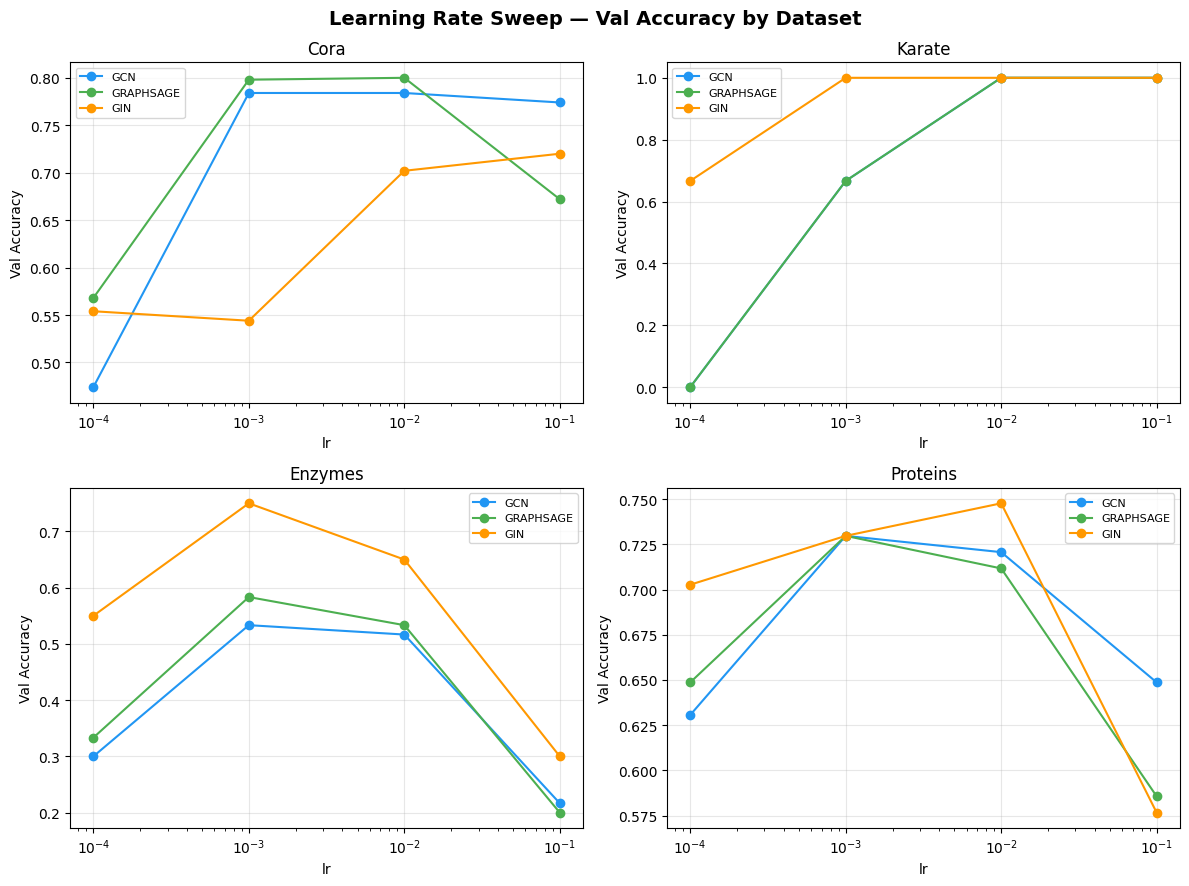

In [4]:
fig, axs = plt.subplots(2, 2, figsize=(12, 9))
plot_sweep(df_lr, 'lr', 'Learning Rate Sweep — Val Accuracy by Dataset', axs)
plt.savefig('lr_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Hidden Channels Sweep
How does model width (embedding size) affect performance?

In [5]:
HC_VALUES = [16, 32, 64, 128]
print('Running hidden channels sweep...')
df_hc = sweep_param('hidden_channels', HC_VALUES, SUPERVISED_MODELS, ALL_DATASETS)
print('Done.')
df_hc

Running hidden channels sweep...


  [1/48] gcn | cora | hidden_channels=16 → val=0.756


  [2/48] gcn | cora | hidden_channels=32 → val=0.778


  [3/48] gcn | cora | hidden_channels=64 → val=0.784


  [4/48] gcn | cora | hidden_channels=128 → val=0.794


...

  [45/48] gin | proteins | hidden_channels=16 → val=0.748


  [46/48] gin | proteins | hidden_channels=32 → val=0.739


  [47/48] gin | proteins | hidden_channels=64 → val=0.757


  [48/48] gin | proteins | hidden_channels=128 → val=0.748
Done.


,hidden_channels,model,dataset,val_acc,test_acc
0,16,gcn,cora,0.756000,0.749000
1,32,gcn,cora,0.778000,0.765000
2,64,gcn,cora,0.784000,0.784000
3,128,gcn,cora,0.794000,0.782000
4,16,gcn,karate,1.000000,1.000000
5,32,gcn,karate,1.000000,1.000000
6,64,gcn,karate,1.000000,1.000000
7,128,gcn,karate,1.000000,1.000000
8,16,gcn,enzymes,0.433333,0.366667
9,32,gcn,enzymes,0.466667,0.416667


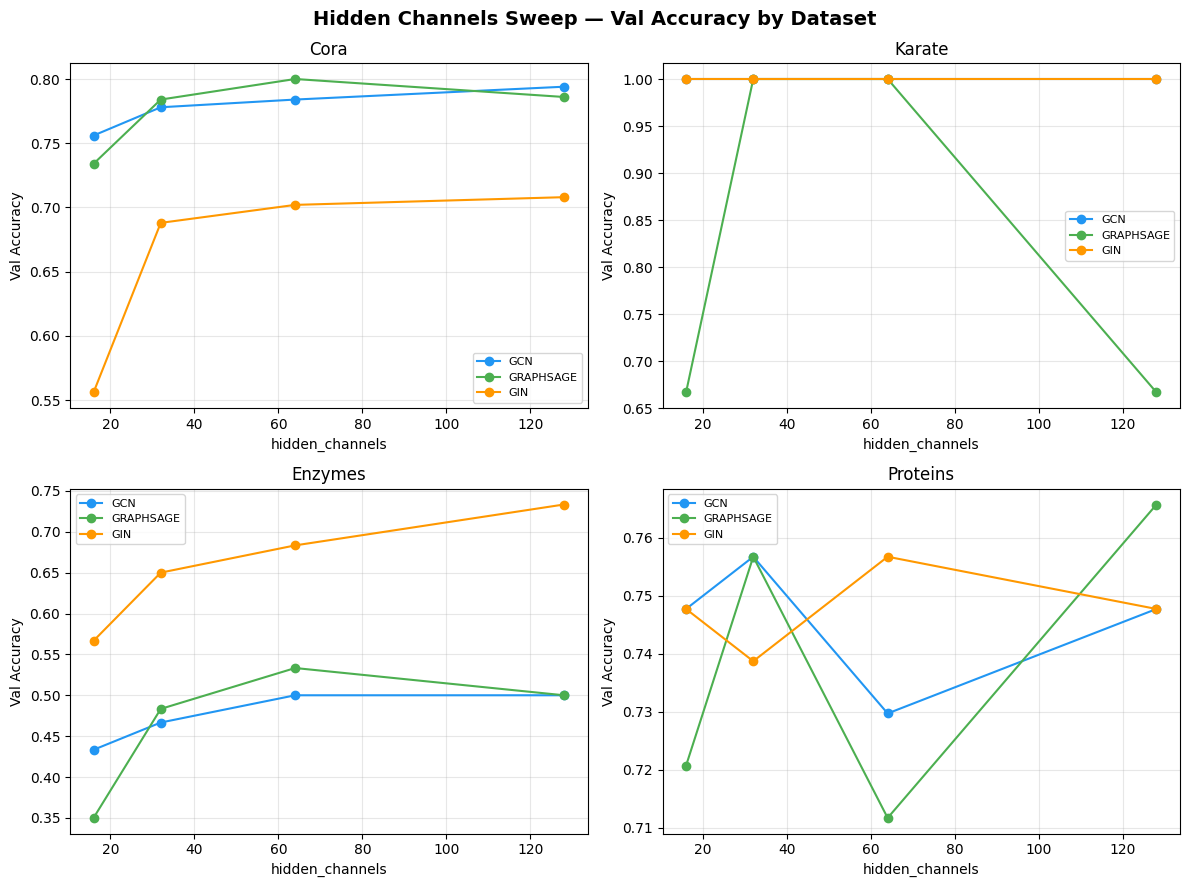

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(12, 9))
plot_sweep(df_hc, 'hidden_channels', 'Hidden Channels Sweep — Val Accuracy by Dataset', axs)
plt.savefig('hc_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Number of Layers Sweep
How deep should the message-passing stack be?

In [7]:
LAYER_VALUES = [2, 3, 4]
print('Running num_layers sweep...')
df_layers = sweep_param('num_layers', LAYER_VALUES, SUPERVISED_MODELS, ALL_DATASETS)
print('Done.')
df_layers

Running num_layers sweep...


  [1/36] gcn | cora | num_layers=2 → val=0.784


  [2/36] gcn | cora | num_layers=3 → val=0.794


  [3/36] gcn | cora | num_layers=4 → val=0.776


  [4/36] gcn | karate | num_layers=2 → val=1.000


...

  [33/36] gin | enzymes | num_layers=4 → val=0.617


  [34/36] gin | proteins | num_layers=2 → val=0.757


  [35/36] gin | proteins | num_layers=3 → val=0.757


  [36/36] gin | proteins | num_layers=4 → val=0.775
Done.


,num_layers,model,dataset,val_acc,test_acc
0,2,gcn,cora,0.784000,0.784000
1,3,gcn,cora,0.794000,0.759000
2,4,gcn,cora,0.776000,0.769000
3,2,gcn,karate,1.000000,1.000000
4,3,gcn,karate,1.000000,1.000000
5,4,gcn,karate,1.000000,1.000000
6,2,gcn,enzymes,0.466667,0.433333
7,3,gcn,enzymes,0.400000,0.350000
8,4,gcn,enzymes,0.416667,0.233333
9,2,gcn,proteins,0.729730,0.785714


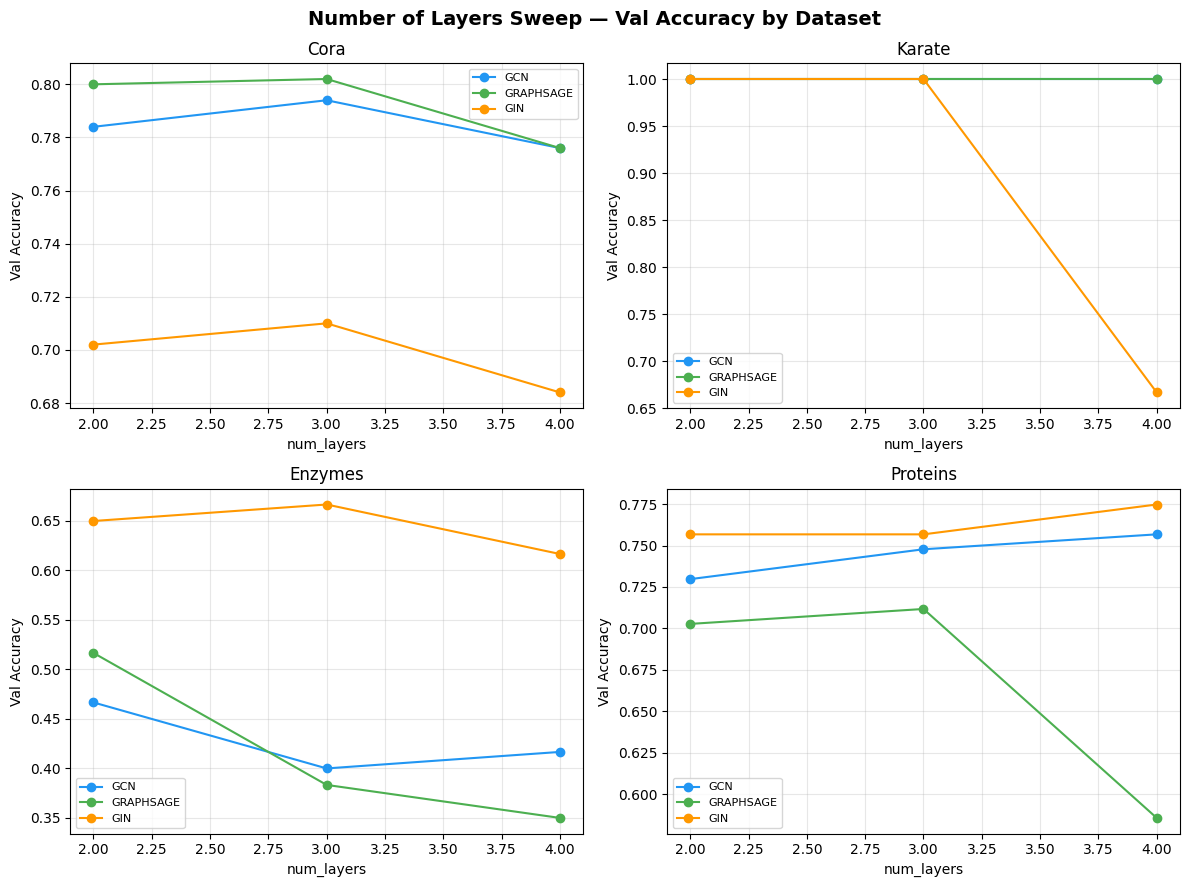

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(12, 9))
plot_sweep(df_layers, 'num_layers', 'Number of Layers Sweep — Val Accuracy by Dataset', axs)
plt.savefig('layers_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Dropout Sweep
How does regularization strength affect performance?

In [9]:
DROPOUT_VALUES = [0.0, 0.3, 0.5, 0.7]
print('Running dropout sweep...')
df_dropout = sweep_param('dropout', DROPOUT_VALUES, SUPERVISED_MODELS, ALL_DATASETS)
print('Done.')
df_dropout

Running dropout sweep...


  [1/48] gcn | cora | dropout=0 → val=0.772


  [2/48] gcn | cora | dropout=0.3 → val=0.782


  [3/48] gcn | cora | dropout=0.5 → val=0.784


  [4/48] gcn | cora | dropout=0.7 → val=0.786


...

  [45/48] gin | proteins | dropout=0 → val=0.739


  [46/48] gin | proteins | dropout=0.3 → val=0.748


  [47/48] gin | proteins | dropout=0.5 → val=0.748


  [48/48] gin | proteins | dropout=0.7 → val=0.748
Done.


,dropout,model,dataset,val_acc,test_acc
0,0.0,gcn,cora,0.772000,0.776000
1,0.3,gcn,cora,0.782000,0.778000
2,0.5,gcn,cora,0.784000,0.784000
3,0.7,gcn,cora,0.786000,0.780000
4,0.0,gcn,karate,0.666667,1.000000
5,0.3,gcn,karate,1.000000,1.000000
6,0.5,gcn,karate,1.000000,1.000000
7,0.7,gcn,karate,1.000000,1.000000
8,0.0,gcn,enzymes,0.566667,0.516667
9,0.3,gcn,enzymes,0.516667,0.516667


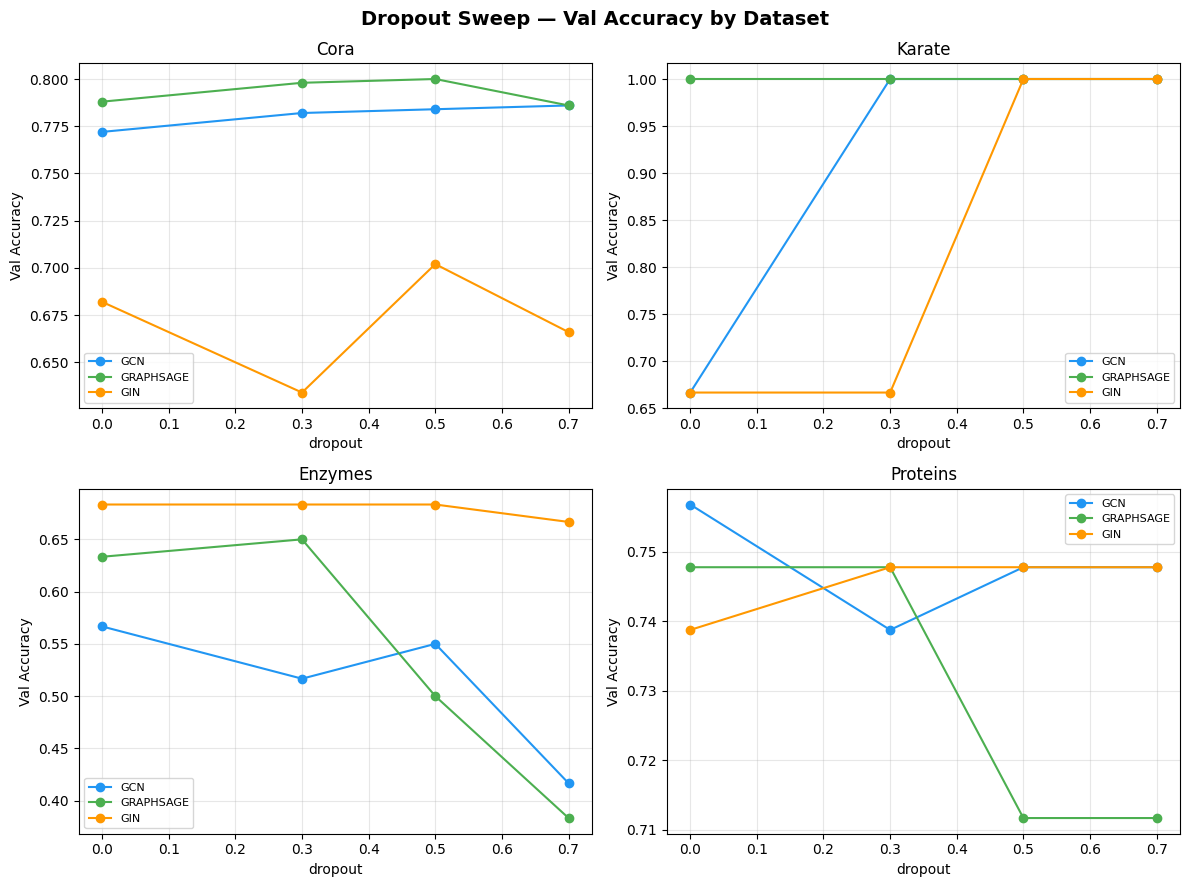

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(12, 9))
plot_sweep(df_dropout, 'dropout', 'Dropout Sweep — Val Accuracy by Dataset', axs)
plt.savefig('dropout_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. DGI Parameter Sweep
For the unsupervised DGI model: how do learning rate and pre-training epochs affect downstream accuracy?

In [11]:
print('Running DGI learning rate sweep...')
df_dgi_lr = sweep_param('lr', LR_VALUES, ['dgi'], ALL_DATASETS,
                        fixed_kwargs={'pretrain_epochs': 150})
print('\nRunning DGI pretrain_epochs sweep...')
df_dgi_pt = sweep_param('pretrain_epochs', [50, 100, 150, 200], ['dgi'], ALL_DATASETS,
                        fixed_kwargs={'lr': 0.001})
print('Done.')

Running DGI learning rate sweep...


  [1/16] dgi | cora | lr=0.0001 → val=0.112


  [2/16] dgi | cora | lr=0.001 → val=0.730


  [3/16] dgi | cora | lr=0.01 → val=0.632


  [4/16] dgi | cora | lr=0.1 → val=0.346


...

  [12/16] dgi | enzymes | pretrain_epochs=200 → val=0.300


  [13/16] dgi | proteins | pretrain_epochs=50 → val=0.586


  [14/16] dgi | proteins | pretrain_epochs=100 → val=0.640


  [15/16] dgi | proteins | pretrain_epochs=150 → val=0.712


  [16/16] dgi | proteins | pretrain_epochs=200 → val=0.694
Done.


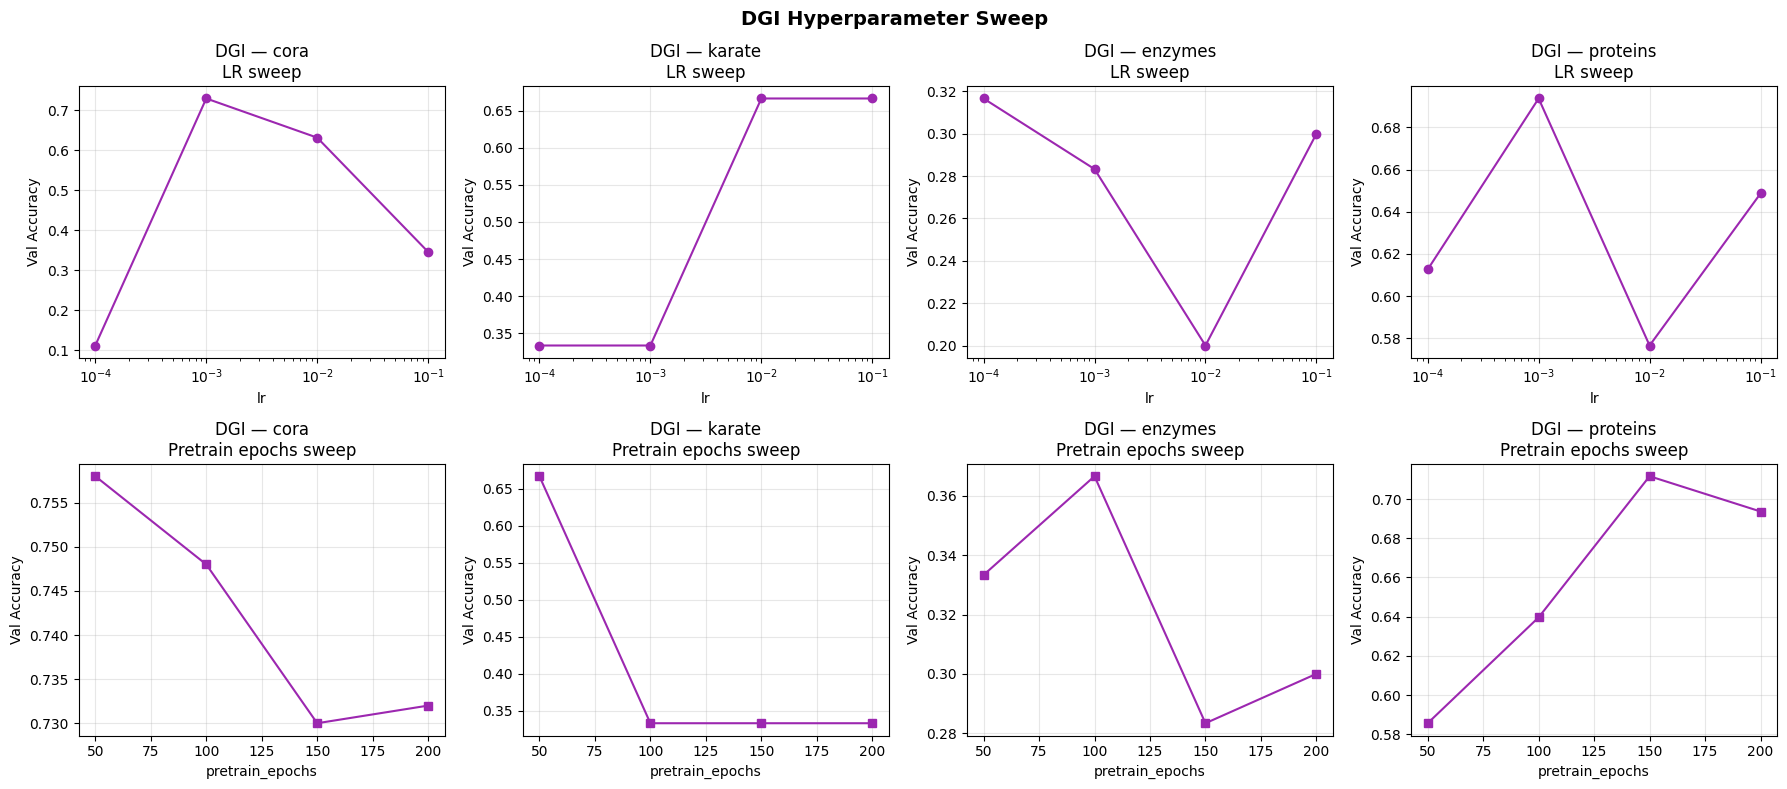

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, dataset in enumerate(ALL_DATASETS):
    # LR sweep
    sub = df_dgi_lr[df_dgi_lr['dataset'] == dataset]
    axes[0, i].plot(sub['lr'], sub['val_acc'], marker='o', color=MODEL_COLORS['dgi'])
    axes[0, i].set_xscale('log')
    axes[0, i].set_title(f'DGI — {dataset}\nLR sweep')
    axes[0, i].set_xlabel('lr')
    axes[0, i].set_ylabel('Val Accuracy')
    axes[0, i].grid(True, alpha=0.3)
    # Pretrain epochs sweep
    sub2 = df_dgi_pt[df_dgi_pt['dataset'] == dataset]
    axes[1, i].plot(sub2['pretrain_epochs'], sub2['val_acc'], marker='s', color=MODEL_COLORS['dgi'])
    axes[1, i].set_title(f'DGI — {dataset}\nPretrain epochs sweep')
    axes[1, i].set_xlabel('pretrain_epochs')
    axes[1, i].set_ylabel('Val Accuracy')
    axes[1, i].grid(True, alpha=0.3)
plt.suptitle('DGI Hyperparameter Sweep', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dgi_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Summary: Best Results per Model and Dataset
Best validation accuracy achieved across all hyperparameter sweeps.

Best val accuracy per (model, dataset):
dataset     cora  karate  enzymes  proteins
model                                      
dgi        0.758   0.667    0.367     0.712
gcn        0.794   1.000    0.567     0.757
gin        0.720   1.000    0.750     0.775
graphsage  0.802   1.000    0.650     0.766


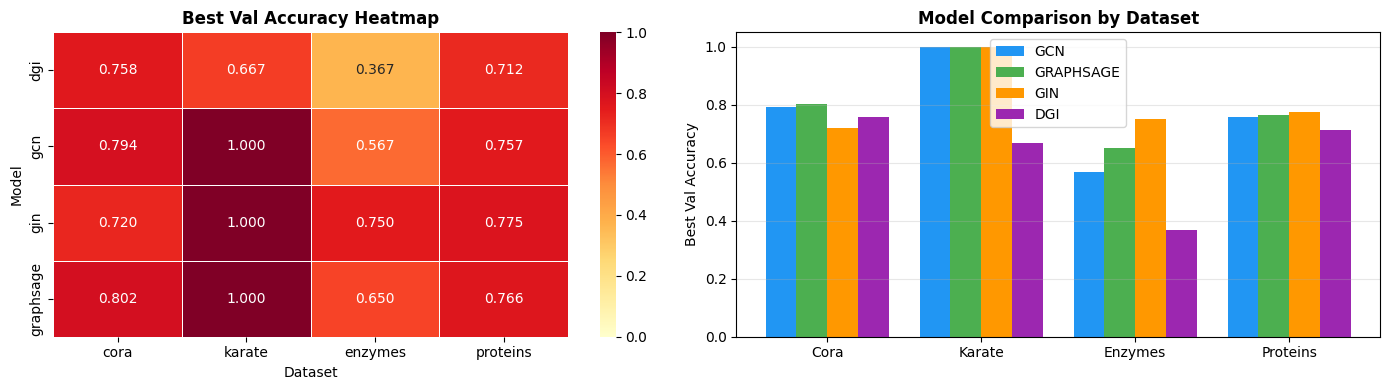

In [13]:
# Combine all supervised sweep results
all_supervised = pd.concat([df_lr, df_hc, df_layers, df_dropout], ignore_index=True)
best_supervised = (
    all_supervised.groupby(['model', 'dataset'])['val_acc']
    .max()
    .reset_index()
    .rename(columns={'val_acc': 'best_val_acc'})
)

# Add DGI best results
all_dgi = pd.concat([df_dgi_lr, df_dgi_pt], ignore_index=True)
best_dgi = (
    all_dgi.groupby(['model', 'dataset'])['val_acc']
    .max()
    .reset_index()
    .rename(columns={'val_acc': 'best_val_acc'})
)

best_all = pd.concat([best_supervised, best_dgi], ignore_index=True)
pivot = best_all.pivot(index='model', columns='dataset', values='best_val_acc')
pivot = pivot[['cora', 'karate', 'enzymes', 'proteins']]

print('Best val accuracy per (model, dataset):')
print(pivot.round(3).to_string())

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Best Val Accuracy Heatmap', fontweight='bold')
axes[0].set_xlabel('Dataset')
axes[0].set_ylabel('Model')

# Bar chart comparing models per dataset
x = np.arange(len(ALL_DATASETS))
width = 0.2
models_order = ['gcn', 'graphsage', 'gin', 'dgi']
for i, model_name in enumerate(models_order):
    if model_name in pivot.index:
        vals = [pivot.loc[model_name, d] if d in pivot.columns else 0 for d in ALL_DATASETS]
        axes[1].bar(x + i * width, vals, width, label=model_name.upper(),
                    color=MODEL_COLORS[model_name])
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels([d.capitalize() for d in ALL_DATASETS])
axes[1].set_ylabel('Best Val Accuracy')
axes[1].set_title('Model Comparison by Dataset', fontweight='bold')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('summary_comparison.png', dpi=120, bbox_inches='tight')
plt.show()